In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize

In [2]:
days = np.array([1, 2, 3, 4, 5, 6, 7, 12, 13, 14])
views = np.array([30000, 62500, 73400, 79000, 82700, 86400, 88500, 93300, 93800, 94300])
likes = np.array([3458, 7743, 9214, 9735, 10200, 10700, 11000, 11700, 11700, 11800])

total_pop = 100000

U_data = total_pop - views  
A_data = likes              
B_data = views - likes 

In [3]:
print('---- INTERPRETASI DATA ----')
print(f'Hari 1: U={U_data[0]}, A={A_data[0]}, B={B_data[0]}')
print(f'Hari 13: U={U_data[-1]}, A={A_data[-1]}, B={B_data[-1]}')
print(f'Total check: {U_data[0] + A_data[0] + B_data[0]} = {total_pop}')

---- INTERPRETASI DATA ----
Hari 1: U=70000, A=3458, B=26542
Hari 13: U=5700, A=11800, B=82500
Total check: 100000 = 100000


In [4]:
def uab_model(t, y, delta, epsilon):
    U, A, B = y
    dUdt = -delta * U * A
    dAdt = delta * U * A - epsilon * A
    dBdt = epsilon * A
    return [dUdt, dAdt, dBdt]

In [5]:
def fit_model(params):
    delta, epsilon = params
    
    if delta <= 0 or epsilon <= 0:
        return 1e10
    
    y0 = [U_data[0], A_data[0], B_data[0]]
    t_span = (0, 13)
    t_eval = days - 1 
    
    try:
        sol = solve_ivp(uab_model, t_span, y0, t_eval=t_eval, 
                       args=(delta, epsilon), method='RK45', rtol=1e-8)        
        if not sol.success:
            return 1e10
      
        U_pred, A_pred, B_pred = sol.y
        
        error_U = np.sum((U_data - U_pred)**2)
        error_A = np.sum((A_data - A_pred)**2) 
        error_B = np.sum((B_data - B_pred)**2)

        total_error = error_U/1e8 + error_A/1e4 + error_B/1e8
        return total_error
    except:
        return 1e10


In [6]:
print('\n---- FITTING PARAMETERS ----')
print('Mencari parameter optimal delta dan epsilon...')

initial_guesses = [
    [1e-6, 0.1], 
    [5e-6, 0.05], 
    [1e-5, 0.15],  
]

best_result = None
best_error = float('inf')

for i, initial_guess in enumerate(initial_guesses):
    print(f'Trying initial guess {i+1}: δ={initial_guess[0]}, ε={initial_guess[1]}')
    
    result = minimize(fit_model, initial_guess, 
                     method='Nelder-Mead',
                     options={'maxiter': 1000})
    
    if result.fun < best_error:
        best_error = result.fun
        best_result = result

delta_opt, epsilon_opt = best_result.x
V0 = (delta_opt * total_pop) / epsilon_opt  


---- FITTING PARAMETERS ----
Mencari parameter optimal delta dan epsilon...
Trying initial guess 1: δ=1e-06, ε=0.1
Trying initial guess 2: δ=5e-06, ε=0.05
Trying initial guess 3: δ=1e-05, ε=0.15


In [7]:
print(f'\n---- HASIL FITTING ----')
print(f'Delta optimal (δ): {delta_opt:.2e}')
print(f'Epsilon optimal (ε): {epsilon_opt:.3f}')
print(f'Virality Index (V₀ = δ*N/ε): {V0:.3f}') 
print(f'Error: {best_error:.6f}')

if V0 > 1:
    print('V₀ > 1: Berpotensi Viral')
else:
    print('V₀ < 1: Tidak Berpotensi Viral')


---- HASIL FITTING ----
Delta optimal (δ): 8.68e-06
Epsilon optimal (ε): 0.303
Virality Index (V₀ = δ*N/ε): 2.865
Error: 3181.985350
V₀ > 1: Berpotensi Viral


In [8]:

y0 = [U_data[0], A_data[0], B_data[0]]
t_span = (0, 15)  
t_eval = np.linspace(0, 15, 200) 

sol_opt = solve_ivp(uab_model, t_span, y0, t_eval=t_eval, 
                   args=(delta_opt, epsilon_opt), method='RK45')

U_pred, A_pred, B_pred = sol_opt.y
views_pred = total_pop - U_pred

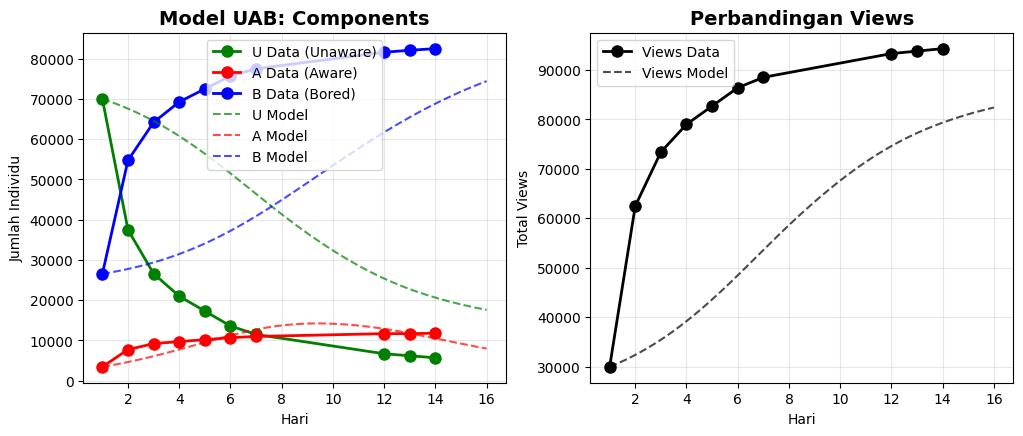

In [9]:
plt.figure(figsize=(12, 10))

# Subplot 1: UAB Components
plt.subplot(2, 2, 1)
plt.plot(days, U_data, 'go-', label='U Data (Unaware)', markersize=8, linewidth=2)
plt.plot(days, A_data, 'ro-', label='A Data (Aware)', markersize=8, linewidth=2)  
plt.plot(days, B_data, 'bo-', label='B Data (Bored)', markersize=8, linewidth=2)

plt.plot(t_eval + 1, U_pred, 'g--', label='U Model', alpha=0.7)
plt.plot(t_eval + 1, A_pred, 'r--', label='A Model', alpha=0.7)
plt.plot(t_eval + 1, B_pred, 'b--', label='B Model', alpha=0.7)

plt.title('Model UAB: Components', fontsize=14, fontweight='bold')
plt.xlabel('Hari')
plt.ylabel('Jumlah Individu')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Views Comparison
plt.subplot(2, 2, 2)
plt.plot(days, views, 'ko-', label='Views Data', markersize=8, linewidth=2)
plt.plot(t_eval + 1, views_pred, 'k--', label='Views Model', alpha=0.7)
plt.title('Perbandingan Views', fontsize=14, fontweight='bold')
plt.xlabel('Hari')
plt.ylabel('Total Views')
plt.legend()
plt.grid(True, alpha=0.3)

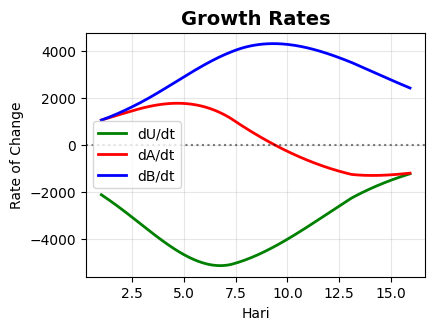

In [10]:
# Subplot 3: Growth Rate Analysis
plt.figure(figsize=(8, 6))

plt.subplot(2, 2, 4)
dt = np.diff(t_eval)
dU_dt = np.diff(U_pred) / dt
dA_dt = np.diff(A_pred) / dt
dB_dt = np.diff(B_pred) / dt

plt.plot(t_eval[:-1] + 1, dU_dt, 'g-', label='dU/dt', linewidth=2)
plt.plot(t_eval[:-1] + 1, dA_dt, 'r-', label='dA/dt', linewidth=2)
plt.plot(t_eval[:-1] + 1, dB_dt, 'b-', label='dB/dt', linewidth=2)
plt.axhline(y=0, color='black', linestyle=':', alpha=0.5)
plt.title('Growth Rates', fontsize=14, fontweight='bold')
plt.xlabel('Hari')
plt.ylabel('Rate of Change')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()